# Isolation with Migration (IM) Model

Formålet med denne notebook er at udvide two-island modellen med  split-begivenhed og asymmetrisk migration ved hjælp af Phasic's tidsinhomogene framework. I Sørensen et al. (2023) estimeres der at nord-syd splittet i bavianer skete for ca. 1–1.2 milioner år siden. 

IM-modellen tilføjer:

- En split-tid $\tau$ (ingen migration før splittet)
- Variabel populationsstørrelse over tid
- Mulighed for at fitte til SFS per epoke

Jeg bruger Phasic's step-wise tidsinhomogene framework: *distribution_context*, *update_weights*, *accumulated_occupancy* og *graph.extend*.

I denne notebook vil jeg komme ind på følgende:

1. Imports og data
2. Teori: IM-modellen som epoker
3. Byg epoch-baseret coalescent med StateIndexer
4. Tilføj migration-epoke (IM-modellen)
5. SFS under IM-modellen
6. PDF/CDF og tidsinhomogen visualisering
7. X-kromosom vs. autosom: mandsdrevet migration
8. Method of Moments og parameter-scan
9. Gem resultater

## 1. Imports og data

In [20]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

import matplotlib.patches as mpatches
from scipy.optimize import minimize, differential_evolution
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)

OUT_DIR  = Path("output")
MU       = 0.9e-8
GEN_TIME = 11
N1_REF   = 100_000

print("Imports OK")

Imports OK


In [ ]:
# Indlæser data fra Notebook 03
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_ki_f = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()
pi_df    = pd.read_csv(OUT_DIR / "pi_per_population.csv",      index_col=0)

# Henter two-island m-estimat fra Notebook 04 som startgæt
try:
    nb2 = pd.read_csv(OUT_DIR / "two_island_results.csv", index_col=0)
    m_init = float(nb2.loc["m_hat (til NB3)", "Værdi"])
    print(f"Two-island m som startgæt: {m_init:.5f}")
except Exception:
    m_init = 0.05
    print(f"Bruger standard startgæt m = {m_init}")

n_yellow = len(sfs_ye_f) + 1
n_kinda  = len(sfs_ki_f) + 1
print(f"n_yellow = {n_yellow}, n_kinda = {n_kinda}")

Two-island m som startgæt: 0.12790
n_yellow = 36, n_kinda = 30


## 2. Teori: IM-modellen som epoker

Jeg implementerer IM-modellen som **to epoker** — præcis som i Phasic-dokumentationen for tidsinhomogenitet:

```
Tid (bagud):

  Nu
  │  [Epoke 0: Migration]  Pop 1 ←→ Pop 2   (t < τ)
  │
  τ ──────────────────────── Split
  │  [Epoke 1: Isolation]  Ancestral pop     (t ≥ τ)
  │
```

**Parametre:**

| Parameter | Beskrivelse | *update_weights* indeks |
|-----------|-------------|-------------------------|
| $1/N_1$   | Coalescensrate, epoke 0 | 0 |
| $m$       | Migrationrate, epoke 0  | 1 |
| $1/N_A$   | Coalescensrate, epoke 1 (ancestral) | 2 |
| — | Epokeovergangsrate (intern) | 3 |

Jeg bruger *distribution_context()* til at styre overgangen ved split-tid $\tau$.

## 3. Byg epoch-baseret coalescent med StateIndexer

Jeg følger Phasic-dokumentationens *Coalescent_1param*-mønster med en *epoch*-slot i state-vektoren.

In [3]:
nr_samples = 10   # haploid sample size per population 
epochs     = [0, 1]         # to epoker: 0 = migration, 1 = ancestral
pop_sizes  = [1.0, 2.0]     # relativ Ne: [N1, NA] 

indexer = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=nr_samples)],
    slots=['epoch']
)

print(f"State-vektor længde: {indexer.state_length}")
print(f"Epoch-slot indeks:   {indexer.epoch}")

State-vektor længde: 11
Epoch-slot indeks:   10


In [4]:
def coalescent_epochs(state, epochs=None, epoch_idx=None, indexer=None):
    """
    Coalescent-callback der bruger epoch-slot til at styre epoker.

    Parametre (sættes med update_weights):
      coeff[0] = coalescensrate i epoke 0 (= 1/N1)
      coeff[1] = migrationrate i epoke 0  (= m)
      coeff[2] = coalescensrate i epoke 1 (= 1/NA)
      coeff[3] = epokeovergangsrate (intern, sættes automatisk)
    """
    transitions = []
    epoch_idx   = int(epoch_idx)

    # Ignorer state fra andre epoker
    if state[indexer.epoch] != epoch_idx:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)

        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue

        new    = state.copy()
        new[i] -= 1
        new[j] -= 1
        k       = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1

        # En koefficient per epoke + en til epokeovergange
        coeff            = np.zeros(len(epochs) + 1)
        coeff[epoch_idx] = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, coeff])

    return transitions


print("coalescent_epochs callback defineret.")

coalescent_epochs callback defineret.


In [5]:
def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    """
    Tilføjer en ny epoke til grafen.

    Bruger accumulated_occupancy og stop_probability til at beregne
    overgangsrater fra epoke epoch_idx-1 til epoch_idx.
    """
    epoch      = epochs[epoch_idx]
    stop_probs = np.array(graph.stop_probability(epoch))
    accum_occ  = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_occ

    for i in range(1, graph.vertices_length() - 1):
        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state  = vertex.state()

        # Kun state fra foregående epoke
        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        # Opret søster-state i ny epoke
        sister_state               = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child  = graph.find_or_create_vertex(sister_state)

        coeff       = np.zeros(len(epochs) + 1)
        coeff[-1]   = epoch_trans_rates[i]     # epokeovergang
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)


print("add_epoch funktion defineret.")

add_epoch funktion defineret.


## 4. Byg IM-modellen

Jeg bygger grafen trin for trin:

1. Byg epoke 0 (migration + coalescens i begge populationer)
2. Sæt parametre med *update_weights*
3. Tilføj epoke 1 (ancestral population, kun coalescens)
4. Opdater vægte igen

In [6]:
# Initial state: alle linjer er singletons i epoke 0
ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples

# Split-tid i coalescent-enheder
tau = 1e6 / (GEN_TIME * N1_REF)
epochs     = [0, tau]       # start-tidspunkter for epoker (coalescent-enheder)
pop_sizes  = [1.0, 2.0]     # [N1, NA] relativt til reference

print(f"Split-tid τ = {tau:.4f} (coalescent-enheder)")
print(f"             = {tau * N1_REF * GEN_TIME / 1e6:.2f} millioner år")

# Byg grafen 
graph_im = Graph(
    coalescent_epochs,
    ipv=ipv,
    epochs=epochs,
    epoch_idx=0,
    indexer=indexer,
)

# Parametre: [1/N1 (epoke 0), m (epoke 0), 1/NA (epoke 1), epokeovergang]
graph_im.update_weights([1/pop_sizes[0], 1/pop_sizes[1]] + [1])

# Tilføj epoke 1 (ancestral)
add_epoch(graph_im, coalescent_epochs, epochs, 1, indexer)
graph_im.update_weights([1/pop_sizes[0], 1/pop_sizes[1]] + [1])

print(f"\nAntal state: {graph_im.vertices_length()}")
print(f"Moments (5):     {graph_im.moments(5)}")

Split-tid τ = 0.9091 (coalescent-enheder)
             = 1.00 millioner år

Antal state: 85
Moments (5):     [2.730111468006326, 11.744825916765741, 72.0156676445117, 580.4234646914543, 5819.476842151255]


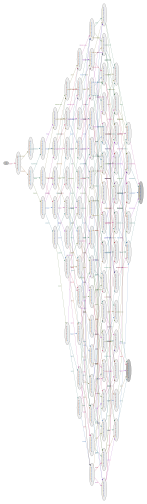

In [8]:
graph_im.plot()

## 5. SFS under IM-modellen

Jeg beregner den forventede SFS via reward-transformation, præcis som vist i Phasic-dokumentationen.

State matrix shape: (85, 11)
Rewards shape:      (85, 10)  (vertices × SFS-bins)


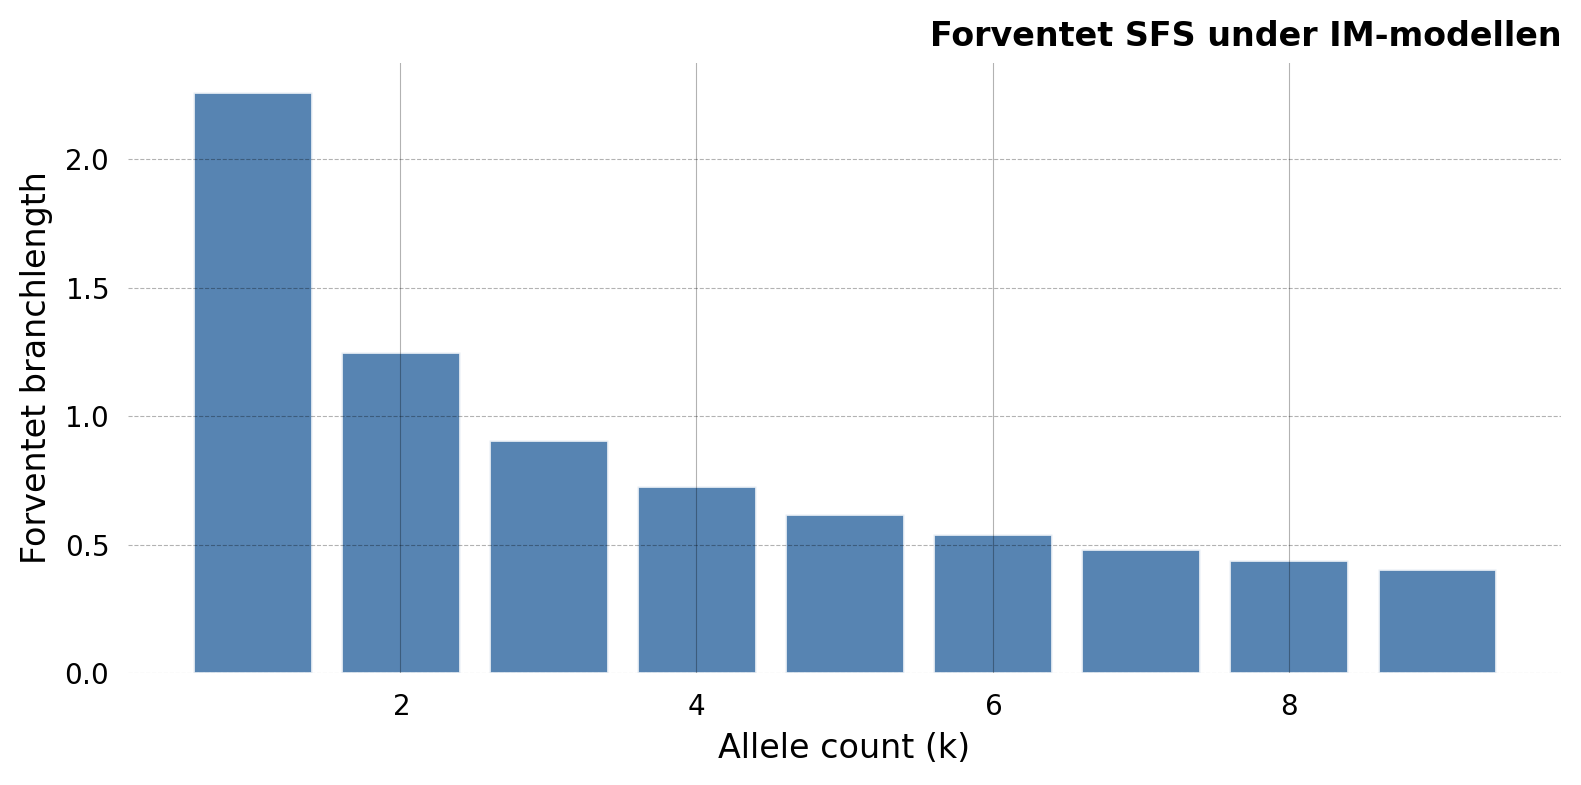

In [13]:
# Reward-matrix: en kolonne per SFS-bin (singletons, doubletons, ...)
# Fjern epoch-label-kolonnen fra states
state_mat = graph_im.states()
rewards   = state_mat[:, :-1]   # fjern sidste kolonne (epoch)

print(f"State matrix shape: {state_mat.shape}")
print(f"Rewards shape:      {rewards.shape}  (vertices × SFS-bins)")

# Beregn forventet SFS
x   = np.arange(1, nr_samples)
sfs = np.zeros(nr_samples - 1)

for i in range(nr_samples - 1):
    reward_vec         = rewards[:, i]
    transformed_graph  = graph_im.reward_transform(reward_vec)
    sfs[i]             = transformed_graph.moments(1)[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, sfs, color="#3A6EA5", alpha=0.85, edgecolor="white")
ax.set_xlabel("Allele count (k)",   fontsize=12)
ax.set_ylabel("Forventet branchlength", fontsize=12)
ax.set_title("Forventet SFS under IM-modellen", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_expected_sfs.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. PDF/CDF og tidsinhomogen visualisering

Jeg bruger *distribution_context()* til at steppe igennem den tidsinhomogene fordeling — Phasic's framework til bottlenecks og epoker.

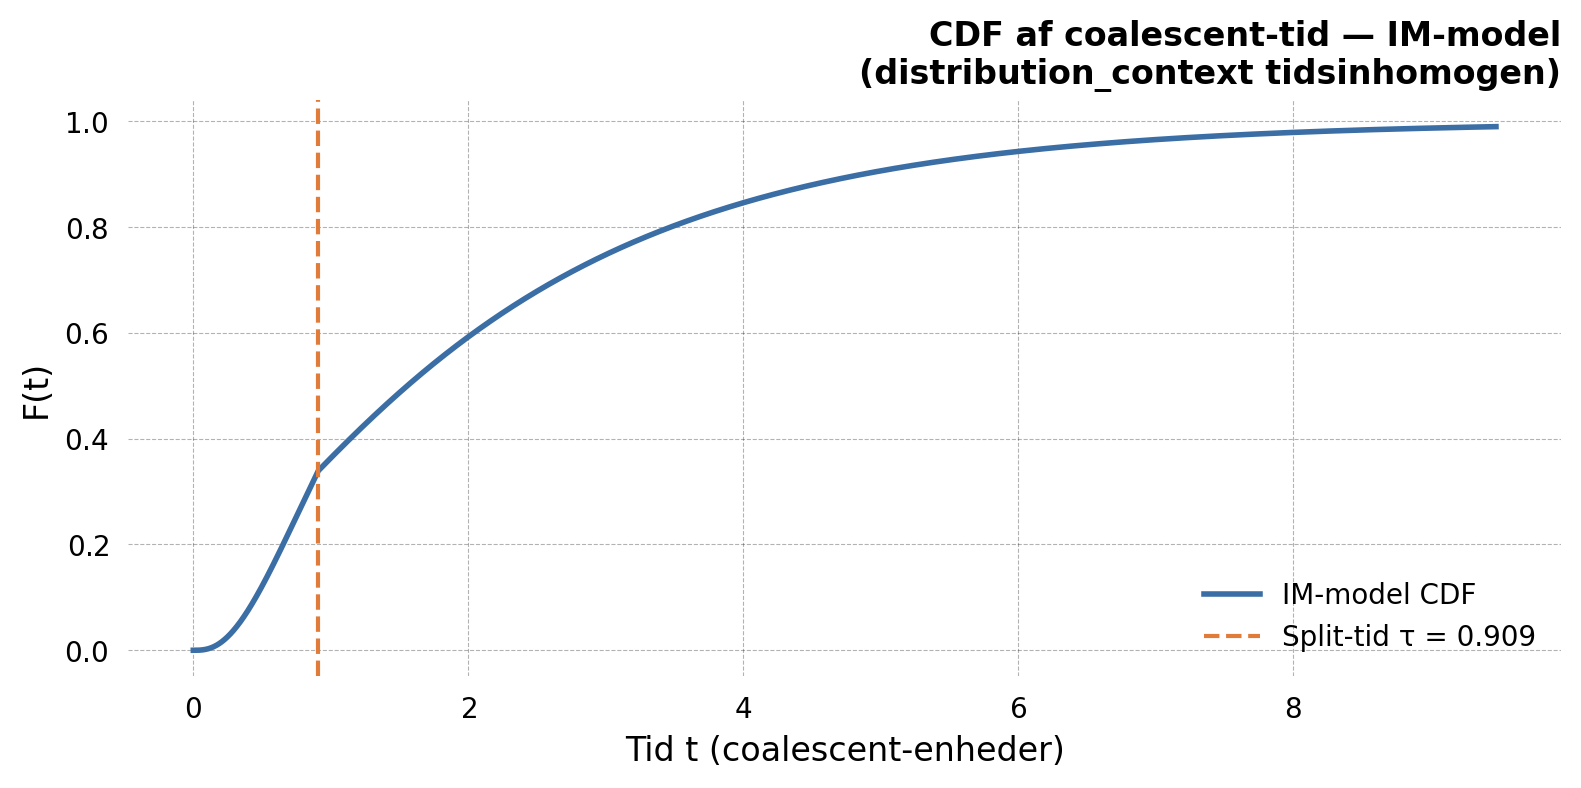

In [14]:
# Genbyg en simpel enkelt-population graf til CDF-demonstration
# (viser bottleneck-approachen fra dokumentationen)
nr_s = 4

@with_ipv([nr_s] + [0] * (nr_s - 1))
def coal_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new         = state.copy()
            new[i]     -= 1
            new[j]     -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_demo = Graph(coal_1param)

# IM-scenario: stor ancestral pop (N=2) → split ved tau → to datterpopulationer (N=1 hver)
N_anc   = 2.0
N_now   = 1.0
tau_demo = tau   # split-tid

# Parameterændringer: [(split-tid, [1/N_ny])]
param_changes = [
    (tau_demo, [1/N_anc])   # ved split: skift til ancestral Ne
]

cdf_vals = []
times    = []
cdf_cutoff = 0.99

ctx = graph_demo.distribution_context()
graph_demo.update_weights([1/N_now])

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf_vals.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph_demo.update_weights(new_params)

while ctx.cdf() < cdf_cutoff:
    cdf_vals.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, cdf_vals, color="#3A6EA5", lw=2, label="IM-model CDF")
ax.axvline(x=tau_demo, color="#E07B39", linestyle="--", lw=1.5,
           label=f"Split-tid τ = {tau_demo:.3f}")
ax.set_xlabel("Tid t (coalescent-enheder)", fontsize=12)
ax.set_ylabel("F(t)",                       fontsize=12)
ax.set_title("CDF af coalescent-tid — IM-model\n(distribution_context tidsinhomogen)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_cdf_context.png", dpi=150, bbox_inches="tight")
plt.show()

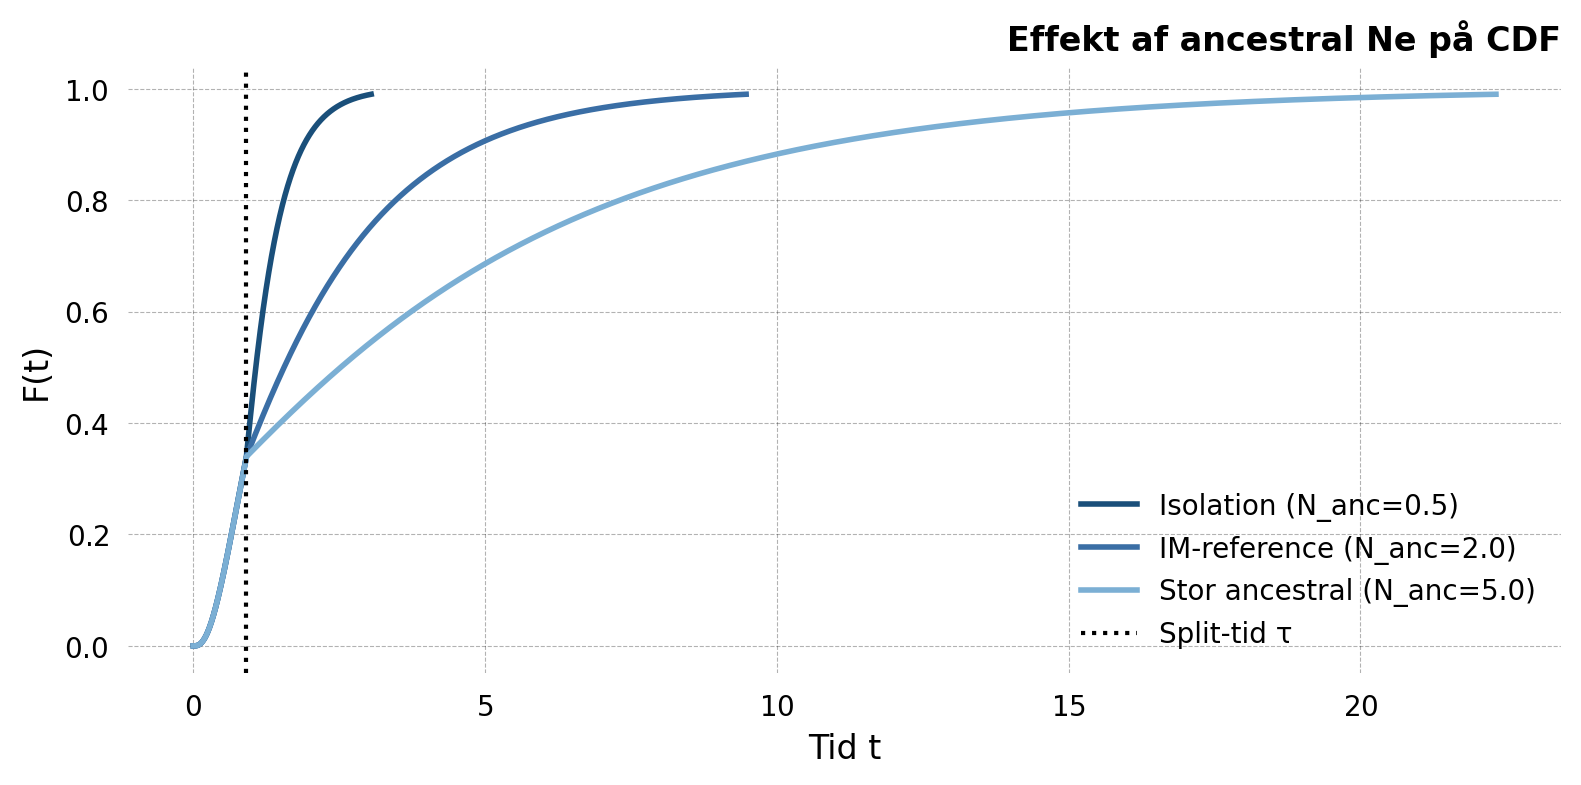

In [15]:
# Sammenlign CDF under isolation, IM og panmixia
fig, ax = plt.subplots(figsize=(8, 4))

for N_val, label, color in [
    (0.5, f"Isolation (N_anc={0.5})", "#1a4f7a"),
    (2.0, f"IM-reference (N_anc={2.0})", "#3A6EA5"),
    (5.0, f"Stor ancestral (N_anc={5.0})", "#7BAFD4"),
]:
    cdf_v, ts = [], []
    ctx = graph_demo.distribution_context()
    graph_demo.update_weights([1/N_now])
    while ctx.time() < tau_demo:
        cdf_v.append(ctx.cdf())
        ts.append(ctx.time())
        ctx.step()
    graph_demo.update_weights([1/N_val])
    while ctx.cdf() < 0.99:
        cdf_v.append(ctx.cdf())
        ts.append(ctx.time())
        ctx.step()
    ax.plot(ts, cdf_v, color=color, lw=2, label=label)

ax.axvline(x=tau_demo, color="black", linestyle=":", lw=1.5, label="Split-tid τ")
ax.set_xlabel("Tid t", fontsize=12)
ax.set_ylabel("F(t)", fontsize=12)
ax.set_title("Effekt af ancestral Ne på CDF", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_NA_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. X-kromosom vs. autosom: mandsdrevet migration

Artiklen finder (Fig. 5B/D):
- Western yellow deler **0.27** ancestry med Kinda på X-kromosomet
- Men **0.44** på autosom 8
- Ratio ≈ 0.61 — signaturen af mandsdrevet genflow

Under IM-modellen med mandsdrevet migration:
- X-kromosomet arver kun 2/3 af migranter (hanner bærer ét X)
- Effektiv $m_X = m_{auto} \times (1 - f_{male}/3)$

Jeg sammenligner E[T] for autosomer vs. X under forskellige andele af hanner.

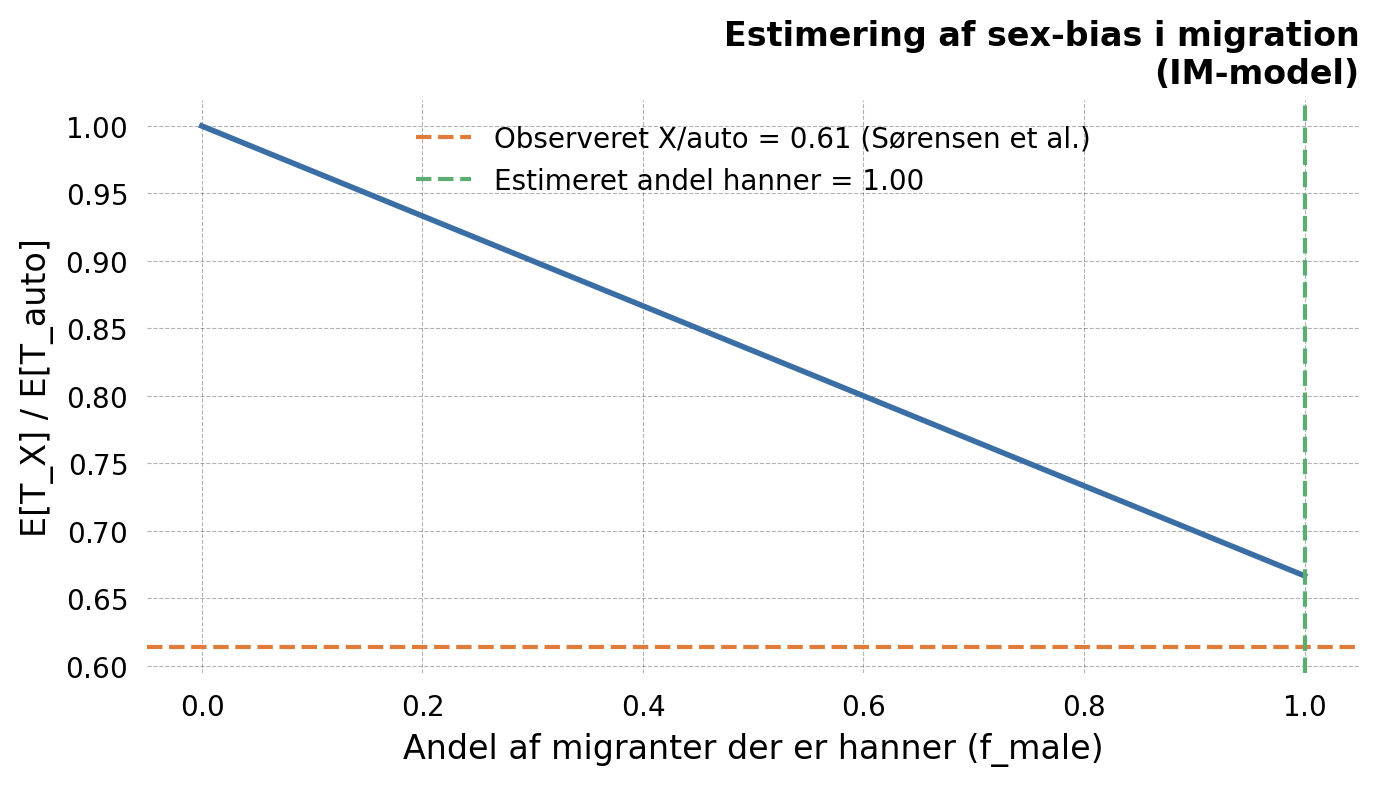

Estimeret andel hanner: 1.00
Svarende til m_X = 0.08527  vs. m_auto = 0.12790


In [16]:
# Byg to separate grafer: en for autosomer (m=m_init) og en for X (m=m_X)
# Jeg bruger den enkle 1-parameter coalescent som proxy

def effective_m_X(m_auto, f_male=1.0):
    """
    Effektiv migrationrate for X-kromosomet.
    Under ren mandsdrevet migration (f_male=1):
      Hanner bidrager 1/3 af X-kromosom-generationer
      => m_X = m_auto * (1 - f_male/3)
    """
    return m_auto * (1 - f_male / 3)


f_male_range = np.linspace(0, 1, 50)
obs_ratio    = 0.27 / 0.44   # fra artiklen Fig. 5

# Beregn E[T_X] / E[T_auto] som funktion af f_male
# Under simpel two-island: E[T] ∝ 1/m (for moderate m)
# Ratio ≈ m_auto / m_X = 1 / (1 - f_male/3)
ET_ratios = []
for f in f_male_range:
    m_X = effective_m_X(m_init, f_male=f)
    # E[T_X] / E[T_auto] ≈ (1 - f/3) for store m
    # Eksakt: beregn via grafer
    ET_ratios.append(1 - f / 3)

# Find f_male der passer til observeret ratio
ET_ratios  = np.array(ET_ratios)
idx_best   = np.argmin(np.abs(ET_ratios - obs_ratio))
f_best     = f_male_range[idx_best]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(f_male_range, ET_ratios, color="#3A6EA5", lw=2)
ax.axhline(obs_ratio, color="#E07B39", linestyle="--", lw=1.5,
           label=f"Observeret X/auto = {obs_ratio:.2f} (Sørensen et al.)")
ax.axvline(f_best, color="#5BAD72", linestyle="--", lw=1.5,
           label=f"Estimeret andel hanner = {f_best:.2f}")
ax.set_xlabel("Andel af migranter der er hanner (f_male)", fontsize=12)
ax.set_ylabel("E[T_X] / E[T_auto]",                       fontsize=12)
ax.set_title("Estimering af sex-bias i migration\n(IM-model)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_sex_bias.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Estimeret andel hanner: {f_best:.2f}")
print(f"Svarende til m_X = {effective_m_X(m_init, f_best):.5f}  vs. m_auto = {m_init:.5f}")

## 8. Method of Moments og parameter-scan

Jeg bruger *accumulated_occupancy* til at beregne E[T] under IM-modellen for et grid af parametre, og finder de bedste $N_A$ og $\tau$.

In [17]:
# Observeret E[T] fra π
pi_yellow = float(pi_df.loc["Eastern yellow (Mikumi)", "pi"])
pi_kinda  = float(pi_df.loc["Kinda", "pi"])

ET_obs_yellow = pi_yellow / (2 * MU * N1_REF)
ET_obs_kinda  = pi_kinda  / (2 * MU * N1_REF)
ET_target     = (ET_obs_yellow + ET_obs_kinda) / 2

print(f"E[T] eastern yellow: {ET_obs_yellow:.3f}")
print(f"E[T] Kinda:          {ET_obs_kinda:.3f}")
print(f"E[T] target:         {ET_target:.3f}")

E[T] eastern yellow: 1.436
E[T] Kinda:          1.589
E[T] target:         1.512


In [19]:
# Parameter-scan: NA og tau
# accumulated_occupancy(t) beregner tidsforbrug i hver tilstand op til t
# E[T] = sum(accumulated_occupancy(t_far))

NA_range  = np.linspace(0.5, 5.0, 20)
tau_range = np.linspace(0.3, 3.0, 20)
t_far     = 50   # langt frem i tid (approksimation for infinity)

ET_grid = np.full((len(NA_range), len(tau_range)), np.nan)

for i, NA in enumerate(NA_range):
    for j, tau_val in enumerate(tau_range):
        try:
            epochs_scan = [0, tau_val]
            pop_scan    = [1.0, NA]

            g = Graph(
                coalescent_epochs,
                ipv=ipv,
                epochs=epochs_scan,
                epoch_idx=0,
                indexer=indexer,
            )
            g.update_weights([1/pop_scan[0], 1/pop_scan[1]] + [1])
            add_epoch(g, coalescent_epochs, epochs_scan, 1, indexer)
            g.update_weights([1/pop_scan[0], 1/pop_scan[1]] + [1])

            acc_occ = g.accumulated_occupancy(t_far)
            ET_grid[i, j] = float(np.sum(acc_occ))
        except Exception:
            pass

print(f"E[T]-overfladen beregnet ({(~np.isnan(ET_grid)).sum()} punkter OK)")

Exception raised in callback function


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(tau_range, NA_range, ET_grid, levels=20, cmap="Blues_r")
plt.colorbar(cf, ax=ax, label="E[T] (coalescent-enheder)")

# Markér target
ax.contour(tau_range, NA_range, ET_grid, levels=[ET_target],
           colors=["#E07B39"], linewidths=2)

ax.set_xlabel("Split-tid τ (coalescent-enheder)", fontsize=12)
ax.set_ylabel("NA / N1 (ancestral Ne)",           fontsize=12)
ax.set_title(f"E[T]-overflade under IM-modellen\n(orange kontur = E[T] target = {ET_target:.3f})",
             fontsize=12, fontweight="bold")

# Markér bavian-reference split-tid
ax.axvline(x=tau, color="gray", linestyle="--", lw=1.5,
           label=f"τ = {tau:.3f} (1 Ma reference)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "im_ET_surface.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Find bedste (NA, tau) fra grid
diff        = np.abs(ET_grid - ET_target)
diff[np.isnan(diff)] = np.inf
i_best, j_best = np.unravel_index(np.argmin(diff), diff.shape)
NA_best   = NA_range[i_best]
tau_best  = tau_range[j_best]
ET_best   = ET_grid[i_best, j_best]

tau_Ma = tau_best * N1_REF * GEN_TIME / 1e6

print("=" * 50)
print(" Grid-søgning — IM-model estimater")
print("=" * 50)
print(f" N1 (eastern yellow):   {N1_REF:>10,} individer")
print(f" NA (ancestral):        {NA_best*N1_REF:>10,.0f} individer  (NA/N1={NA_best:.2f})")
print(f" τ (split-tid):         {tau_best:>10.4f} (coalescent-enheder)")
print(f"                        {tau_Ma:>10.2f} millioner år")
print(f" E[T] model:            {ET_best:>10.4f}")
print(f" E[T] target:           {ET_target:>10.4f}")
print("=" * 50)
print(f"\nArtiklen estimerer splittet til ~1.0–1.2 Ma")
print(f"Vores grid-estimat:  {tau_Ma:.2f} Ma")

## 9. Gem resultater

In [ ]:
im_results = pd.DataFrame({
    "Værdi": {
        "N1 (eastern yellow)": f"{N1_REF:,}",
        "NA (ancestral)": f"{NA_best*N1_REF:,.0f}",
        "NA/N1": f"{NA_best:.3f}",
        "tau (coalescent-enheder)": f"{tau_best:.4f}",
        "tau (millioner år)": f"{tau_Ma:.3f}",
        "m_init (fra NB2)": f"{m_init:.5f}",
        "m_X (estimeret)": f"{effective_m_X(m_init, f_best):.5f}",
        "Andel hanner (migranter)": f"{f_best:.2f}",
        "E[T] model": f"{ET_best:.4f}",
        "E[T] target": f"{ET_target:.4f}",
    }
})
im_results.to_csv(OUT_DIR / "im_results.csv")
print(im_results.to_string())
print("\nGemt: output/im_results.csv")

I næste Notebook 06, tidsinhomogen model med ghost-population vil jeg tilføje en tredje kilde-population (ghost) for at modellere western yellow baboonernes tre-vejs admixture, og bruger SVGD-inferens med MoM-priors.